In [1]:
!pip install requests pandas tqdm beautifulsoup4

In [2]:
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm
import pandas as pd
import numpy as np
import time
import re

In [3]:
# # ============================================================
# # BLOCK 1: CATEGORIES & RELEVANT TOPICS
# # ============================================================
# categories_topics = {
#     "Data Science": [
#         "data-science",
#         "machine-learning",
#         "deep-learning",
#         "artificial-intelligence",
#         "nlp",
#         "computer-vision",
#         "generative-ai",
#         "llm"
#     ],
#     "Web Development": [
#         "html",
#         "css",
#         "javascript",
#         "react",
#         "nodejs"
#     ],
#     "Cybersecurity": [
#         "cybersecurity",
#         "malware",
#         "pentesting",
#         "security-tools"
#     ],
#     "Full Stack": [
#         "mern",
#         "mean",
#         "mevn",
#         "full-stack",
#         "web-development",
#         "web-app",
#         "crud",
#         "rest-api",
#         "graphql"
#     ],
#     "Database": [
#         "mysql",
#         "postgresql",
#         "mongodb",
#         "sqlite",
#         "redis",
#         "firebase",
#         "supabase",
#         "prisma"
#     ],
#     "JavaScript Frameworks": [
#         "react",
#         "nextjs",
#         "vue",
#         "nuxt",
#         "angular",
#         "svelte",
#         "solidjs",
#         "astro"
#     ],
#     "UI UX": [
#         "ui",
#         "ux",
#         "dashboard",
#         "admin-panel",
#         "landing-page",
#         "portfolio",
#         "ecommerce",
#         "blog"
#     ],
#     "API": [
#         "rest-api",
#         "graphql",
#         "swagger",
#         "openapi",
#         "api",
#         "postman"
#     ]
# }

In [4]:
dataset = []
seen_urls = set()

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}


def parse_counter(text):
    if not text:
        return 0

    raw = text.replace(",", "").strip().lower()

    try:
        if raw.endswith("k"):
            return int(float(raw[:-1]) * 1000)

        elif raw.endswith("m"):
            return int(float(raw[:-1]) * 1000000)

        match = re.search(r"\d+(?:\.\d+)?", raw)

        return int(float(match.group())) if match else 0

    except (ValueError, TypeError):
        return 0


for category, topics in categories_topics.items():

    for topic in tqdm(topics, desc=category):

        url = f"https://github.com/topics/{topic}"

        try:
            response = requests.get(
                url,
                headers=headers,
                timeout=10
            )

        except requests.exceptions.RequestException:
            continue

        if response.status_code != 200:
            continue

        soup = BeautifulSoup(
            response.text,
            "html.parser"
        )

        repo_articles = soup.find_all("article")

        for article in repo_articles:

            h3_tag = article.find("h3")

            if not h3_tag:
                continue

            a_tags = h3_tag.find_all("a")

            if len(a_tags) < 2:
                continue

            owner = a_tags[0].get_text(strip=True)
            repo_name = a_tags[1].get_text(strip=True)

            repo_href = a_tags[1].get("href", "").strip()

            if not repo_href:
                continue

            repo_url = f"https://github.com{repo_href}"

            if repo_url in seen_urls:
                continue

            seen_urls.add(repo_url)

            # ------------------------------------------------
            # STARS
            # ------------------------------------------------

            stars = 0

            star_tag = article.select_one(
                'a[href*="/stargazers"]'
            )

            if star_tag:

                stars = parse_counter(
                    star_tag.get_text(" ", strip=True)
                )

            if stars == 0:

                star_span = article.find(
                    "span",
                    id=lambda x:
                    x and "repo-stars-counter" in x
                )

                if star_span:

                    stars = parse_counter(
                        star_span.get("title", "")
                        or
                        star_span.get_text(
                            " ",
                            strip=True
                        )
                    )

            # ------------------------------------------------
            # PROGRAMMING LANGUAGE
            # ------------------------------------------------

            lang_span = article.find(
                "span",
                itemprop="programmingLanguage"
            )

            language = (
                lang_span.get_text(strip=True)
                if lang_span
                else "Unknown"
            )

            # ------------------------------------------------
            # STORE DATA
            # ------------------------------------------------

            dataset.append({
                "Category": category,
                "Topic": topic,
                "Repository": repo_name,
                "Owner": owner,
                "Repository_URL": repo_url,
                "Language": language,
                "Stars": stars
            })


In [5]:
# df = pd.DataFrame(dataset)
# df.drop_duplicates(subset="Repository_URL",inplace=True)
# df.reset_index(drop=True, inplace=True)
# df.to_csv("github_topics_scraped.csv",index=False)


In [6]:
# print(df.head(10))
# print("Total repositories:", len(df))
# print("Total columns:", len(df.columns))

In [4]:
df.shape

(781, 7)

In [3]:
#Data Understanding
df = pd.read_csv("github_topics_scraped.csv")
print(df)

         Category         Topic                                  Repository  \
0    Data Science  data-science                            ML-For-Beginners   
1    Data Science  data-science                                    superset   
2    Data Science  data-science                           30-Days-Of-Python   
3    Data Science  data-science                                scikit-learn   
4    Data Science  data-science                                       keras   
..            ...           ...                                         ...   
776           API       postman                     postman-code-generators   
777           API       postman                                       Swell   
778           API       postman  node-express-mongodb-jwt-rest-api-skeleton   
779           API       postman                                     httpyac   
780           API       postman                    WebDev-DevOps-Cohort-3.0   

                Owner                              

In [9]:
df.head(10)

,Category,Topic,Repository,Owner,Repository_URL,Language,Stars
0,Data Science,data-science,ML-For-Beginners,microsoft,https://github.com/microsoft/ML-For-Beginners,Jupyter Notebook,90095
1,Data Science,data-science,superset,apache,https://github.com/apache/superset,Python,74613
2,Data Science,data-science,30-Days-Of-Python,Asabeneh,https://github.com/Asabeneh/30-Days-Of-Python,Python,72764
3,Data Science,data-science,scikit-learn,scikit-learn,https://github.com/scikit-learn/scikit-learn,Python,67153
4,Data Science,data-science,keras,keras-team,https://github.com/keras-team/keras,Python,64274
5,Data Science,data-science,pandas,pandas-dev,https://github.com/pandas-dev/pandas,Python,49629
6,Data Science,data-science,Made-With-ML,GokuMohandas,https://github.com/GokuMohandas/Made-With-ML,Jupyter Notebook,49332
7,Data Science,data-science,Summer2027-Internships,SimplifyJobs,https://github.com/SimplifyJobs/Summer2027-Int...,Python,47107
8,Data Science,data-science,airflow,apache,https://github.com/apache/airflow,Python,46717
9,Data Science,data-science,streamlit,streamlit,https://github.com/streamlit/streamlit,Python,45677


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 781 entries, 0 to 780
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Category        781 non-null    str  
 1   Topic           781 non-null    str  
 2   Repository      781 non-null    str  
 3   Owner           781 non-null    str  
 4   Repository_URL  781 non-null    str  
 5   Language        781 non-null    str  
 6   Stars           781 non-null    int64
dtypes: int64(1), str(6)
memory usage: 109.0 KB


In [11]:
df.isnull().sum()

Category          0
Topic             0
Repository        0
Owner             0
Repository_URL    0
Language          0
Stars             0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.columns

Index(['Category', 'Topic', 'Repository', 'Owner', 'Repository_URL',
       'Language', 'Stars'],
      dtype='str')

In [14]:
df.describe()

,Stars
count,781.000000
mean,32569.571063
std,44837.516591
min,6.000000
25%,4951.000000
50%,18250.000000
75%,41611.000000
max,474892.000000


In [15]:
df.dtypes

Category            str
Topic               str
Repository          str
Owner               str
Repository_URL      str
Language            str
Stars             int64
dtype: object

In [16]:
#Data Cleaning
df.isnull().sum()

Category          0
Topic             0
Repository        0
Owner             0
Repository_URL    0
Language          0
Stars             0
dtype: int64

In [17]:
#Language has missing values
df["Language"] = df["Language"].fillna("Unknown")


In [18]:
#Duplicate Records
df.duplicated().sum()

np.int64(0)

In [19]:
# Ensure numeric metrics are proper integers
df["Stars"] = pd.to_numeric(df["Stars"], errors="coerce").fillna(0).astype(int)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 781 entries, 0 to 780
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Category        781 non-null    str  
 1   Topic           781 non-null    str  
 2   Repository      781 non-null    str  
 3   Owner           781 non-null    str  
 4   Repository_URL  781 non-null    str  
 5   Language        781 non-null    str  
 6   Stars           781 non-null    int64
dtypes: int64(1), str(6)
memory usage: 109.0 KB


In [21]:
#Invalid Values
df[df["Stars"] < 0]

,Category,Topic,Repository,Owner,Repository_URL,Language,Stars


In [22]:
#Inconsistent Categories
df["Language"].unique()

<ArrowStringArray>
['Jupyter Notebook',           'Python',          'Unknown',
       'JavaScript',              'C++',             'HTML',
               'Go',              'MDX',       'TypeScript',
              'Lua',             'Rust',            'Shell',
             'Ruby',              'CSS',            'Astro',
       'Dockerfile',              'PHP',         'Assembly',
             'Text',                'C',             'Java',
             'SCSS',              'Vue',               'C#',
         'Markdown',                'R',         'Nunjucks',
       'PureScript',         'Mustache',          'Clojure',
           'Kotlin',             'Dart',           'Svelte',
            'Swift',             'Vala',              'Pug',
       'Vim Script']
Length: 37, dtype: str

In [23]:
df["Language"] = df["Language"].str.strip()

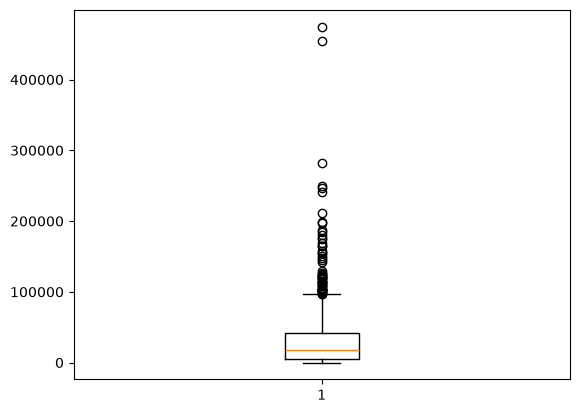

In [24]:
#Outlier Analysis
#Method 1 — Boxplot
import matplotlib.pyplot as plt

plt.boxplot(df["Stars"])
plt.show()

C:\Users\LVST\AppData\Local\Temp\ipykernel_7216\2876048815.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Stars"], vert=False)


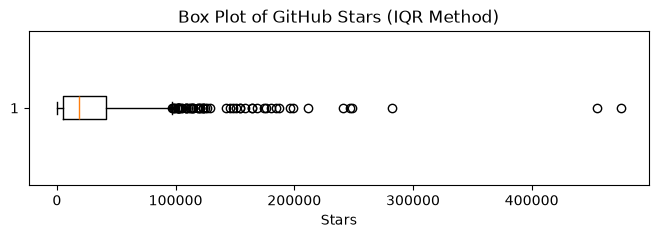

In [25]:
#Method 1 — IQR
Q1 = df["Stars"].quantile(0.25)
Q3 = df["Stars"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Stars"] < lower) | (df["Stars"] > upper)]
import matplotlib.pyplot as plt

plt.figure(figsize=(8,2))
plt.boxplot(df["Stars"], vert=False)
plt.title("Box Plot of GitHub Stars (IQR Method)")
plt.xlabel("Stars")
plt.show()

In [26]:
#Data Validation 
df.info()

df.isnull().sum()

df.duplicated().sum()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 781 entries, 0 to 780
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Category        781 non-null    str  
 1   Topic           781 non-null    str  
 2   Repository      781 non-null    str  
 3   Owner           781 non-null    str  
 4   Repository_URL  781 non-null    str  
 5   Language        781 non-null    str  
 6   Stars           781 non-null    int64
dtypes: int64(1), str(6)
memory usage: 109.1 KB


,Stars
count,781.000000
mean,32569.571063
std,44837.516591
min,6.000000
25%,4951.000000
50%,18250.000000
75%,41611.000000
max,474892.000000


In [27]:
df.isnull().sum()

Category          0
Topic             0
Repository        0
Owner             0
Repository_URL    0
Language          0
Stars             0
dtype: int64

In [28]:
#SPRINT 2 --- Exploratory Data Analysis & Visualization 

In [29]:
#Descriptive Analysis
# 1. Numerical Descriptive Analysis (Stars and Forks)
df[["Stars"]].describe()

,Stars
count,781.000000
mean,32569.571063
std,44837.516591
min,6.000000
25%,4951.000000
50%,18250.000000
75%,41611.000000
max,474892.000000


In [30]:
# 2. Central Tendency & Dispersion metrics
df[["Stars"]].agg(["mean", "median", "std", "var", "min", "max"])

,Stars
mean,3.256957e+04
median,1.825000e+04
std,4.483752e+04
var,2.010403e+09
min,6.000000e+00
max,4.748920e+05


In [31]:
# 3. Categorical Overview (Category, Topic, Language)
df[["Category", "Topic", "Language"]].describe()

,Category,Topic,Language
count,781,781,781
unique,8,53,37
top,Full Stack,data-science,TypeScript
freq,166,20,203


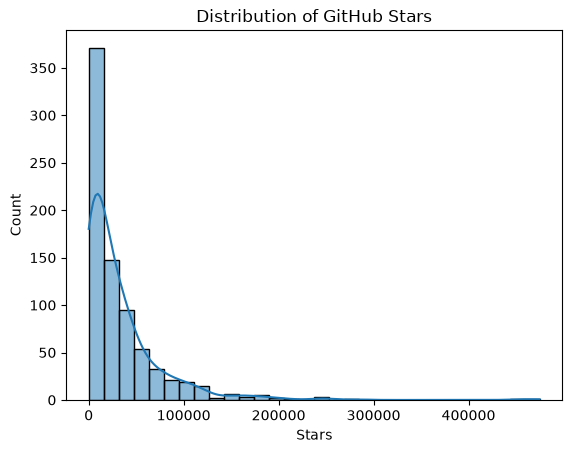

In [32]:
#2. Univariate Analysis
#A. Distribution of Stars
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Stars"], bins=30, kde=True)
plt.title("Distribution of GitHub Stars")
plt.show()

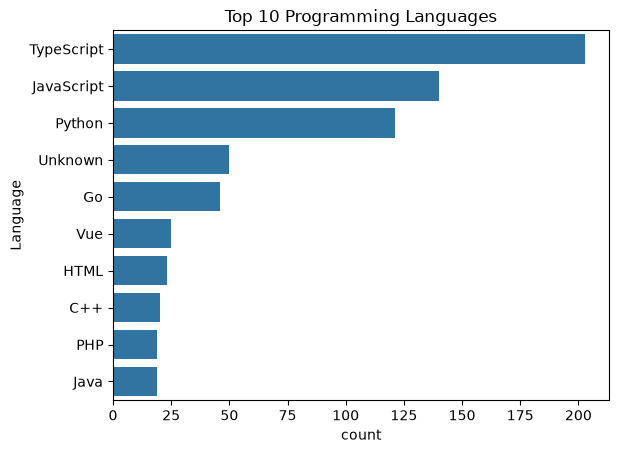

In [33]:
#B. Top Programming Languages
sns.countplot(y=df["Language"],
              order=df["Language"].value_counts().index[:10])
plt.title("Top 10 Programming Languages")
plt.show()

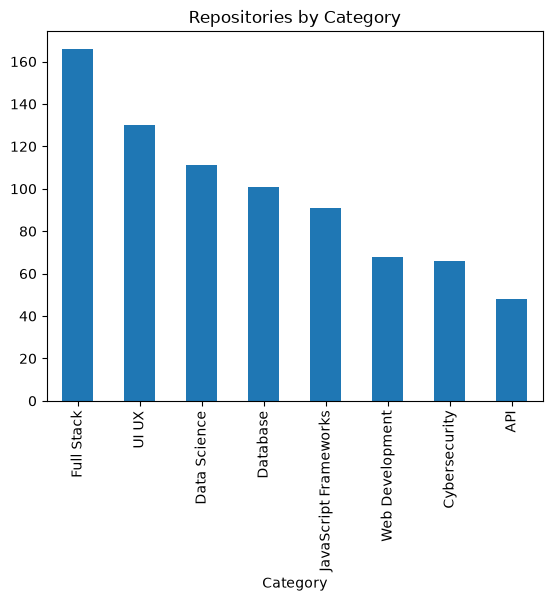

In [34]:
#C. Category Frequency
df["Category"].value_counts().plot(kind="bar")
plt.title("Repositories by Category")
plt.show()

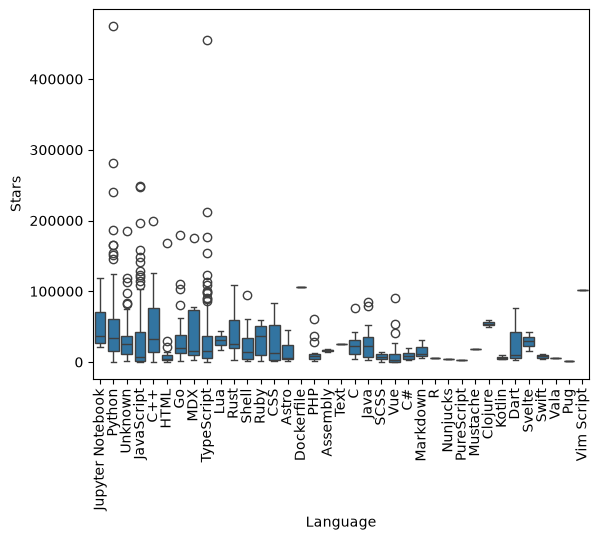

In [35]:
#3. Bivariate Analysis
#A. Language vs Stars
sns.boxplot(data=df, x="Language", y="Stars")
plt.xticks(rotation=90)
plt.show()

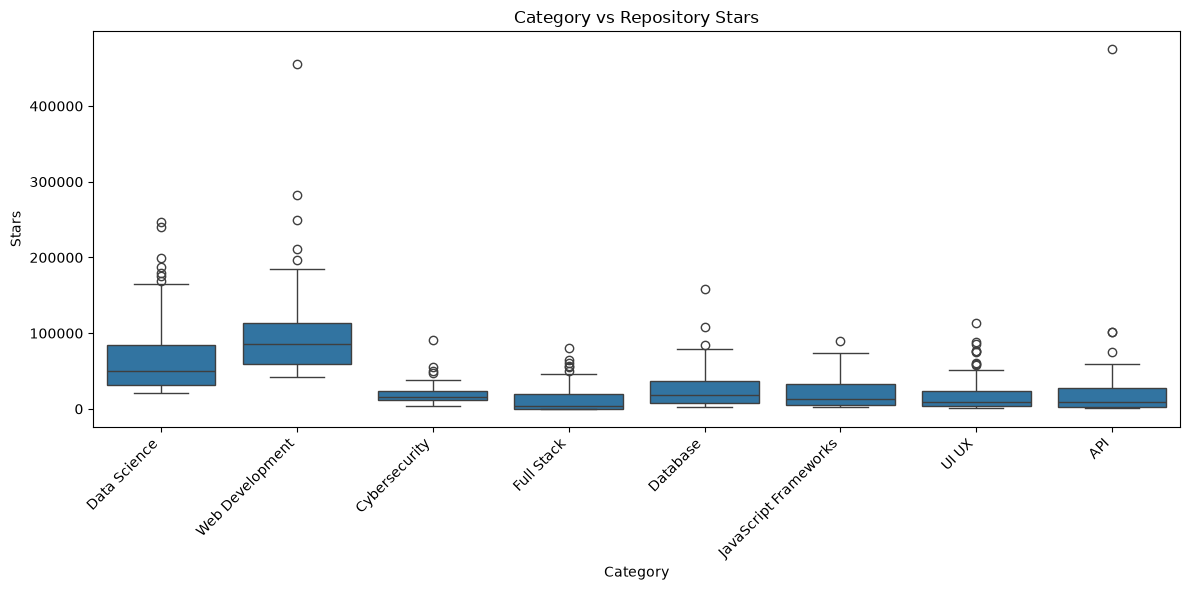

In [36]:
#CATEOGORY VS REPOSITORY STARS
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Category",
    y="Stars"
)

plt.xticks(rotation=45, ha="right")
plt.title("Category vs Repository Stars")
plt.xlabel("Category")
plt.ylabel("Stars")

plt.tight_layout()
plt.show()

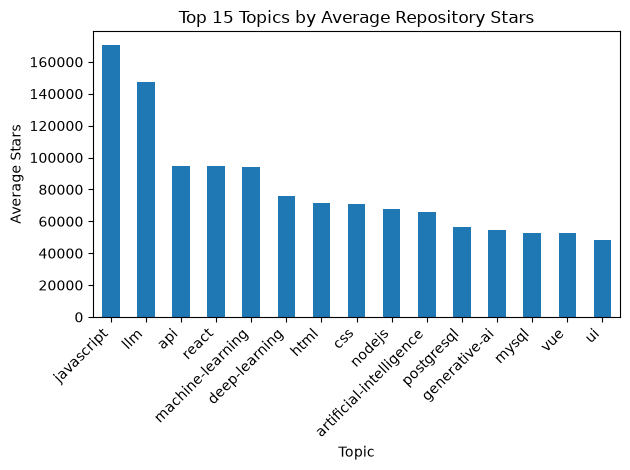

In [37]:
# 3. Topic vs Average Stars
avg_topic = df.groupby("Topic")["Stars"].mean().sort_values(ascending=False).head(15)
avg_topic.plot(kind="bar")
plt.title("Top 15 Topics by Average Repository Stars")
plt.xlabel("Topic")
plt.ylabel("Average Stars")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [38]:
#feature engineering
df["Log_Stars"] = np.log10(df["Stars"] + 1)
df["Repo_Name_Length"] = df["Repository"].astype(str).str.len()
df["Owner_Name_Length"] = df["Owner"].astype(str).str.len()
df["Repo_Word_Count"] = df["Repository"].astype(str).apply(lambda x: len(x.replace("_", "-").split("-")))

In [39]:
df[["Stars", "Log_Stars", "Repo_Name_Length", "Owner_Name_Length", "Repo_Word_Count"]].head()

,Stars,Log_Stars,Repo_Name_Length,Owner_Name_Length,Repo_Word_Count
0,90095,4.954706,16,9,3
1,74613,4.872820,8,6,1
2,72764,4.861923,17,8,4
3,67153,4.827072,12,12,2
4,64274,4.808042,5,10,1


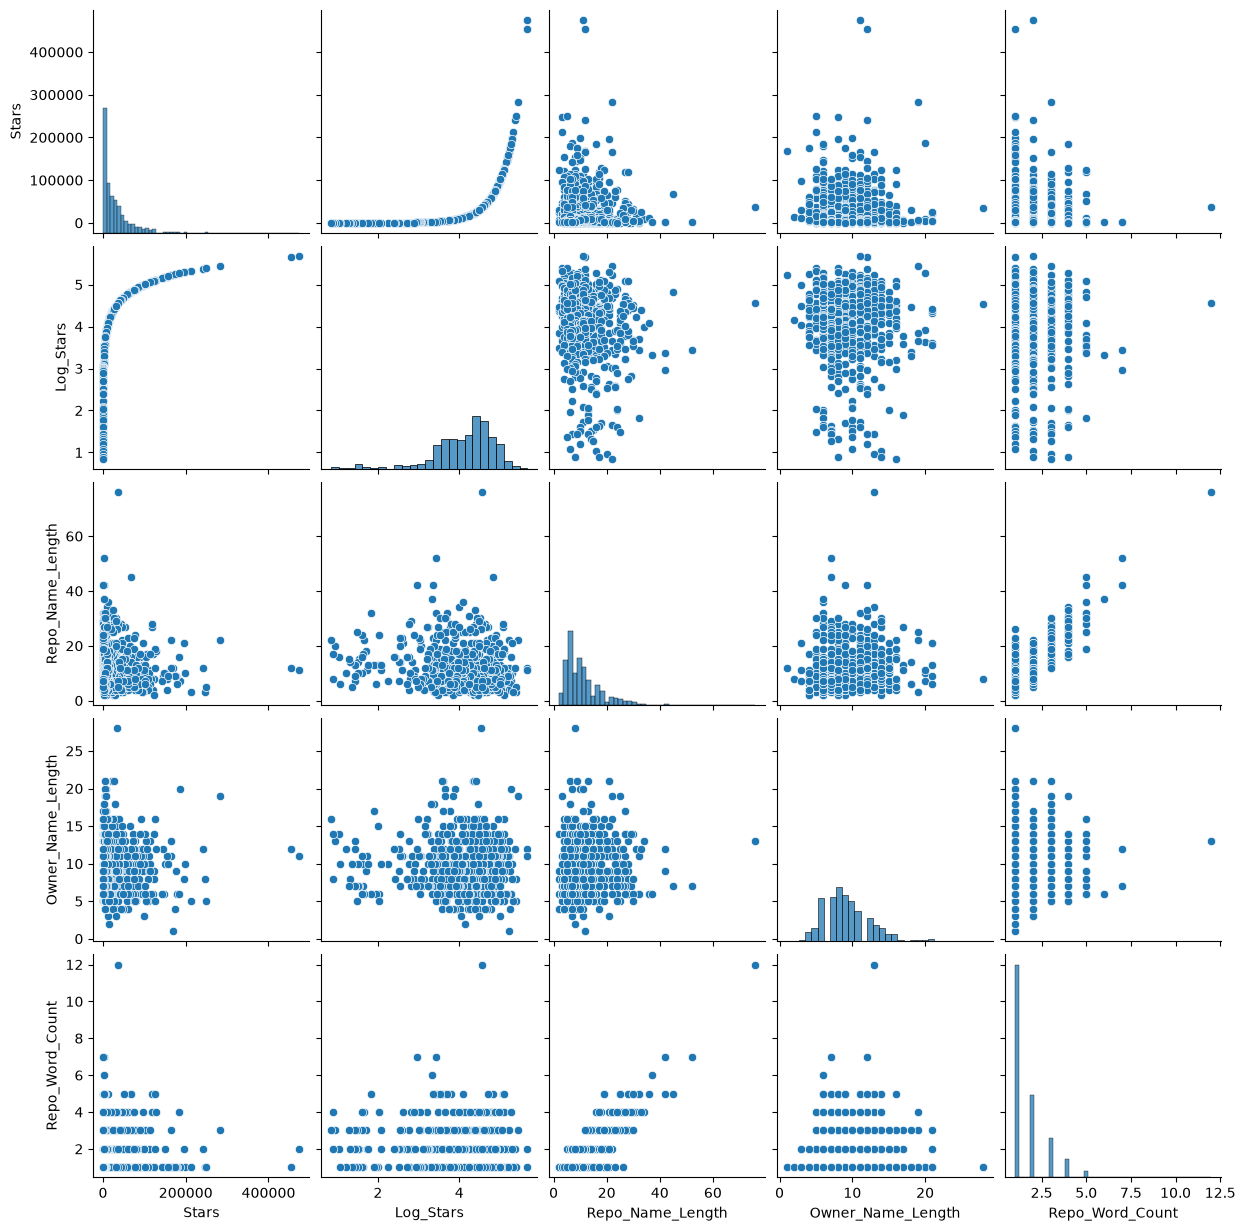

In [40]:
#4. Multivariate Analysis
sns.pairplot(df[["Stars", "Log_Stars", "Repo_Name_Length", "Owner_Name_Length", "Repo_Word_Count"]])
plt.show()

In [41]:
# 5. Group-Based Analysis
group = df.groupby("Category").agg({"Stars": ["mean", "median", "max", "count"]})
group

Stars                       
                               mean   median     max count
Category                                                  
API                    27343.437500   8490.0  474892    48
Cybersecurity          19854.242424  16064.0   90897    66
Data Science           67958.711712  49863.0  246977   111
Database               25290.623762  18237.0  158249   101
Full Stack             11401.963855   3578.5   80185   166
JavaScript Frameworks  20579.912088  13639.0   90197    91
UI UX                  16874.084615   9093.0  113817   130
Web Development        99368.691176  85736.5  454959    68

In [42]:
#Language wise summary
df.groupby("Language").agg({"Stars": ["mean", "median", "max", "count"]})


Stars                        
                           mean    median     max count
Language                                               
Assembly           16464.500000   16464.5   18698     2
Astro              15638.285714    5017.0   45569     7
C                  27308.500000   22739.0   76183     8
C#                  9495.833333    8750.0   20524     6
C++                50487.500000   32871.0  198783    20
CSS                29554.571429   12215.0   82776     7
Clojure            54310.000000   54310.0   59544     2
Dart               29459.666667    9253.0   76235     3
Dockerfile        105600.000000  105600.0  105600     1
Go                 30130.869565   19441.0  180061    46
HTML               14087.043478    4760.0  168885    23
Java               26381.578947   23134.0   84703    19
JavaScript         29928.378571    7729.0  249051   140
Jupyter Notebook   52308.666667   36836.0  119086    15
Kotlin              6129.500000    5770.5    9310     4
Lua                30578.000000   30578.0   44080     2
MDX                44082.444444   15713.0  174713     9
Markdown           16160.000000   10967.0   31199     3
Mustache           17786.000000   17786.0   17786     1
Nunjucks            3615.000000    3615.0    3615     1
PHP                12220.894737    8522.0   61364    19
Pug                 1672.000000    1672.0    1672     1
PureScript          3168.000000    3168.0    3168     1
Python             51304.371901   33872.0  474892   121
R                   5682.000000    5682.0    5682     1
Ruby               31492.285714   36464.0   58748     7
Rust               40384.176471   25090.0  108358    17
SCSS                7365.500000    7365.5   14223     2
Shell              27387.375000   13903.0   94815     8
Svelte             29051.000000   29051.0   42590     2
Swift               7875.000000    7875.0   12010     2
Text               25913.000000   25913.0   25913     1
TypeScript         29083.241379   14950.0  454959   203
Unknown            35411.460000   25501.5  184796    50
Vala                5338.000000    5338.0    5338     1
Vim Script        102092.000000  102092.0  102092     1
Vue                11542.840000    3378.0   90197    25

In [43]:
#6. Pivot Table Analysis
#Pivot 1
pivot_table = pd.pivot_table(df,
    values="Stars",
    index="Category",
    columns="Language",
    aggfunc="mean",
    fill_value=0
)
pivot_table


Language,Assembly,Astro,C,C#,C++,CSS,Clojure,Dart,Dockerfile,Go,...,SCSS,Shell,Svelte,Swift,Text,TypeScript,Unknown,Vala,Vim Script,Vue
Category,,,,,,,,,,,,,,,,,,,,,
API,0.0,0.000000,0.000000,7361.0,0.000000,0.000000,0.0,2891.0,0.0,14519.400000,...,0.0,0.0,0.0,0.0,0.0,10876.500000,27290.250000,0.0,102092.0,0.000000
Cybersecurity,16464.5,0.000000,9209.666667,0.0,31983.500000,12215.000000,0.0,0.0,0.0,20243.454545,...,0.0,10531.5,0.0,0.0,25913.0,28711.666667,17020.000000,0.0,0.0,0.000000
Data Science,0.0,0.000000,0.000000,0.0,76674.333333,0.000000,0.0,0.0,0.0,121165.333333,...,0.0,25618.0,0.0,0.0,0.0,68221.777778,46416.900000,0.0,0.0,0.000000
Database,0.0,0.000000,48453.666667,0.0,22764.250000,0.000000,49076.0,9253.0,0.0,21054.125000,...,0.0,0.0,0.0,0.0,0.0,19167.063830,32104.000000,0.0,0.0,0.000000
Full Stack,0.0,0.000000,0.000000,8344.5,1778.333333,0.000000,0.0,0.0,0.0,18436.900000,...,508.0,7437.5,0.0,0.0,0.0,21221.976190,14214.818182,0.0,0.0,1726.142857
JavaScript Frameworks,0.0,5306.333333,0.000000,20524.0,0.000000,2095.000000,0.0,0.0,0.0,36597.500000,...,0.0,0.0,29051.0,0.0,0.0,18263.229167,14311.750000,0.0,0.0,27959.000000
UI UX,0.0,15993.333333,22739.000000,6200.5,76041.000000,3109.500000,59544.0,76235.0,0.0,18144.333333,...,14223.0,31364.0,0.0,7875.0,0.0,17059.448276,32488.777778,5338.0,0.0,13577.666667
Web Development,0.0,45569.000000,0.000000,0.0,124668.500000,62117.666667,0.0,0.0,105600.0,86812.000000,...,0.0,94815.0,0.0,0.0,0.0,106144.000000,108385.200000,0.0,0.0,0.000000


In [44]:
# Pivot 2 — Language-wise Stars
pd.pivot_table(
    df,
    values="Stars",
    index="Language",
    aggfunc=["mean", "max"]
)

,mean,max
,Stars,Stars
Language,,
Assembly,16464.500000,18698
Astro,15638.285714,45569
C,27308.500000,76183
C#,9495.833333,20524
C++,50487.500000,198783
CSS,29554.571429,82776
Clojure,54310.000000,59544
Dart,29459.666667,76235


In [45]:
#7. Crosstab Analysis
#Category vs Language
pd.crosstab(df["Category"], df["Language"])

Language,Assembly,Astro,C,C#,C++,CSS,Clojure,Dart,Dockerfile,Go,...,SCSS,Shell,Svelte,Swift,Text,TypeScript,Unknown,Vala,Vim Script,Vue
Category,,,,,,,,,,,,,,,,,,,,,
API,0,0,0,1,0,0,0,1,0,5,...,0,0,0,0,0,4,4,0,1,0
Cybersecurity,2,0,3,0,4,1,0,0,0,11,...,0,2,0,0,1,6,5,0,0,0
Data Science,0,0,0,0,6,0,0,0,0,3,...,0,1,0,0,0,9,10,0,0,0
Database,0,0,3,0,4,0,1,1,0,8,...,0,0,0,0,0,47,2,0,0,0
Full Stack,0,0,0,2,3,0,0,0,0,10,...,1,2,0,0,0,42,11,0,0,14
JavaScript Frameworks,0,3,0,1,0,1,0,0,0,4,...,0,0,2,0,0,48,4,0,0,8
UI UX,0,3,2,2,1,2,1,1,0,3,...,1,2,0,2,0,29,9,1,0,3
Web Development,0,1,0,0,2,3,0,0,1,2,...,0,1,0,0,0,18,5,0,0,0


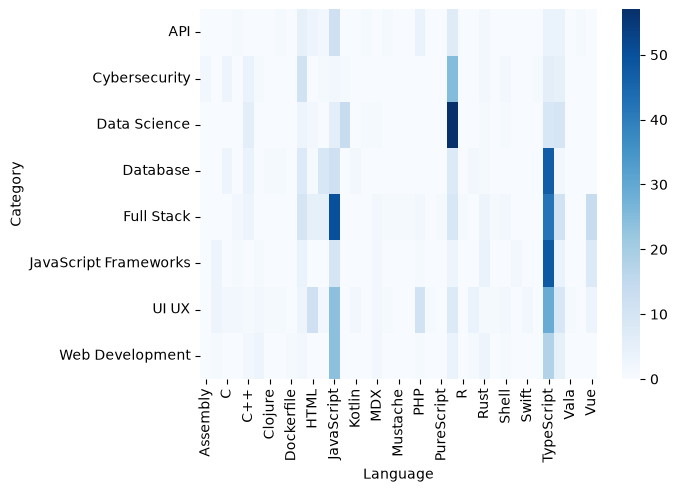

In [46]:
#Heatmap
ct=pd.crosstab(df["Category"],df["Language"])

sns.heatmap(ct,cmap="Blues")
plt.show()

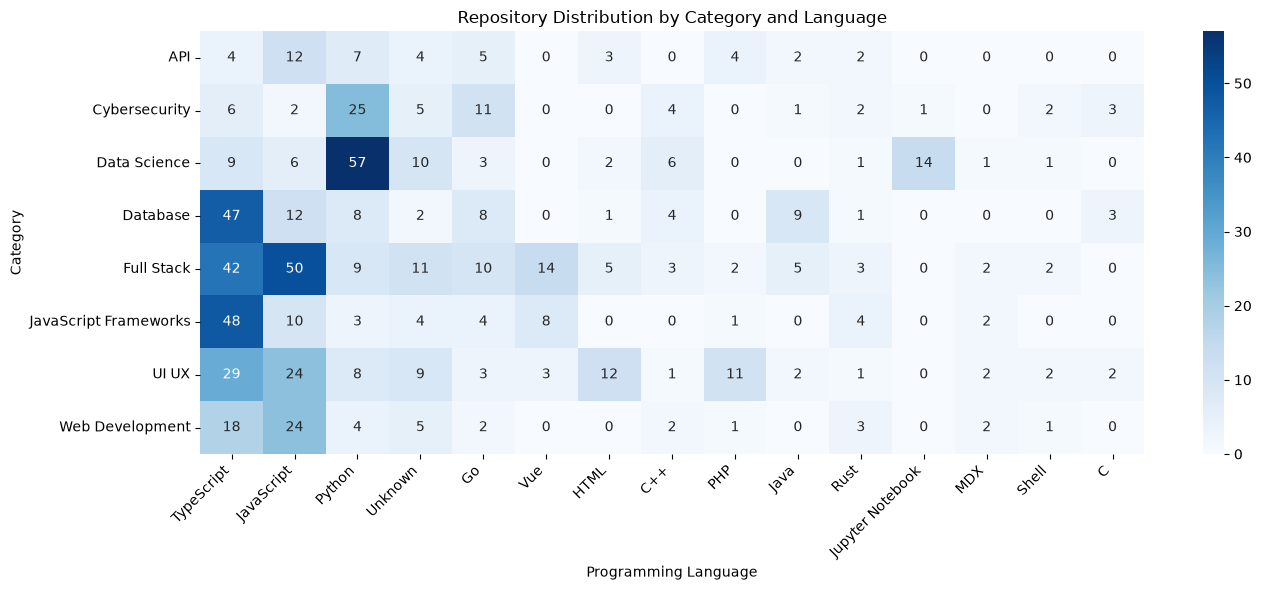

In [47]:
# Heatmap - Category vs Top Languages for only limietd ones

top_languages = df["Language"].value_counts().head(15).index

ct = pd.crosstab(
    df["Category"],
    df["Language"]
)

ct = ct[top_languages]

plt.figure(figsize=(14, 6))

sns.heatmap(
    ct,
    cmap="Blues",
    annot=True,
    fmt="d"
)

plt.title("Repository Distribution by Category and Language")
plt.xlabel("Programming Language")
plt.ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [48]:
# 8. Correlation Analysis
# Correlation Matrix
corr = df[["Stars", "Log_Stars", "Repo_Name_Length", "Owner_Name_Length", "Repo_Word_Count"]].corr()
corr

,Stars,Log_Stars,Repo_Name_Length,Owner_Name_Length,Repo_Word_Count
Stars,1.000000,0.635088,-0.078998,-0.015734,-0.065987
Log_Stars,0.635088,1.000000,-0.179213,-0.068784,-0.176354
Repo_Name_Length,-0.078998,-0.179213,1.000000,0.120589,0.866416
Owner_Name_Length,-0.015734,-0.068784,0.120589,1.000000,0.048424
Repo_Word_Count,-0.065987,-0.176354,0.866416,0.048424,1.000000


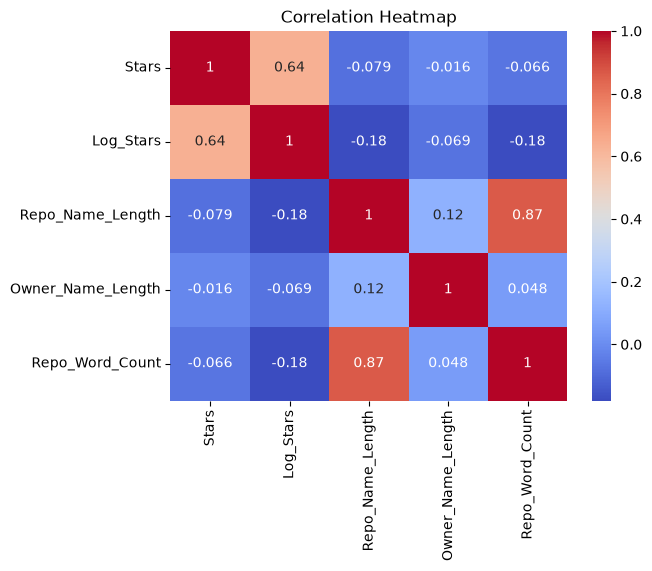

In [49]:
#Heatmap
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [50]:
#9. Data Visualization (Matplotlib + Seaborn)
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")

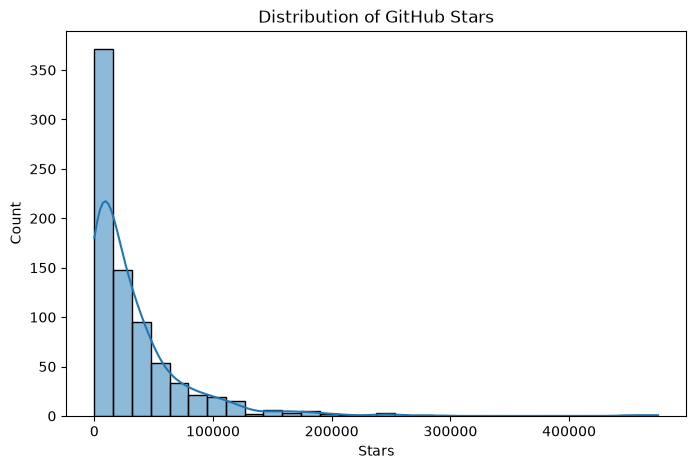

In [51]:
#A. Histogram — Distribution of Stars
plt.figure(figsize=(8,5))
sns.histplot(df["Stars"], bins=30, kde=True)
plt.title("Distribution of GitHub Stars")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()

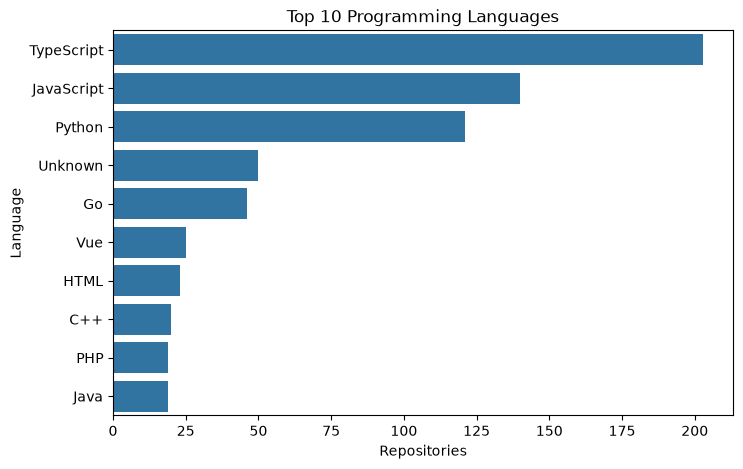

In [52]:
#B. Count Plot — Top Programming Languages
plt.figure(figsize=(8,5))

sns.countplot(
    y=df["Language"],
    order=df["Language"].value_counts().index[:10]
)

plt.title("Top 10 Programming Languages")
plt.xlabel("Repositories")
plt.ylabel("Language")
plt.show()

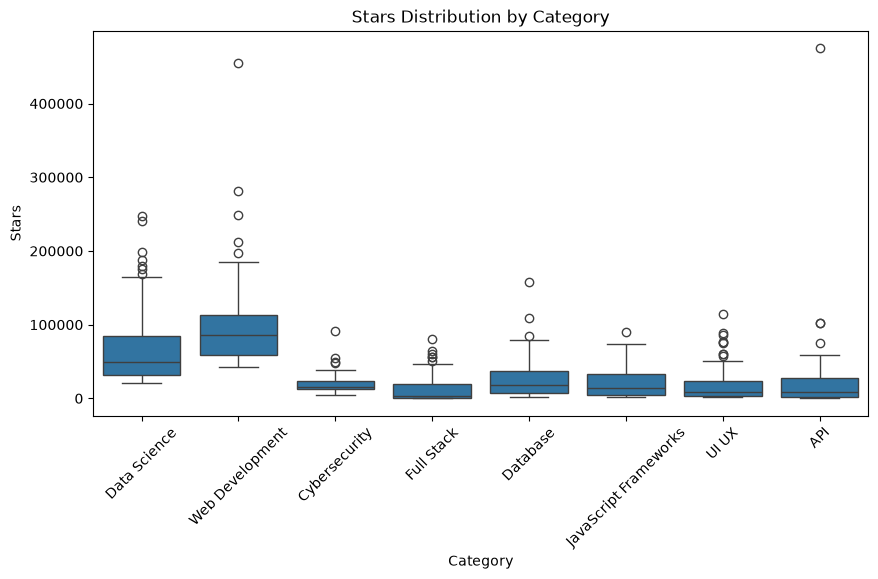

In [53]:
#C. Box Plot — Stars by Category
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Category", y="Stars")
plt.xticks(rotation=45)
plt.title("Stars Distribution by Category")
plt.show()

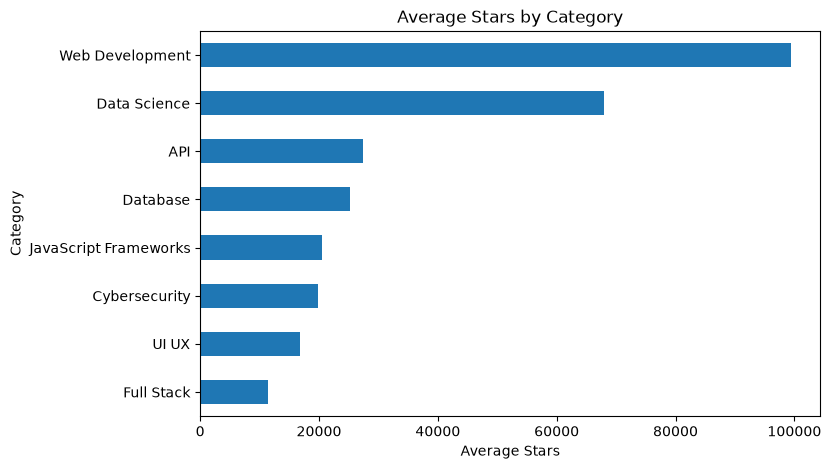

In [54]:
#F. Bar Chart — Average Stars
avg_stars = df.groupby("Category")["Stars"].mean().sort_values()

plt.figure(figsize=(8,5))

avg_stars.plot(kind="barh")

plt.title("Average Stars by Category")
plt.xlabel("Average Stars")
plt.show()

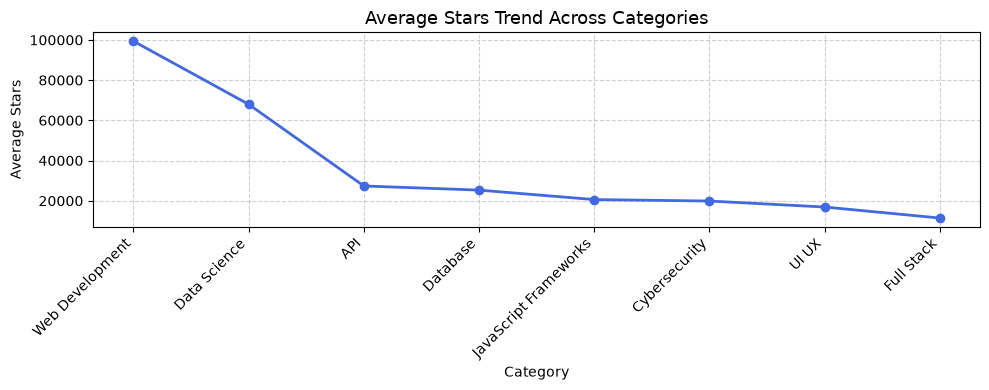

In [55]:
#G.Average Stars by Category
# Trend of Average Stars across Domain Categories
category_trend = df.groupby("Category")["Stars"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
plt.plot(category_trend.index, category_trend.values, marker="o", color="royalblue", linewidth=2)
plt.title("Average Stars Trend Across Categories", fontsize=13)
plt.xlabel("Category")
plt.ylabel("Average Stars")
plt.xticks(rotation=45, ha="right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [56]:
#11. Business Insights

In [57]:
# Top 10 Most Popular Repositories
top_repo = df.nlargest(10, "Stars")[
    ["Repository",  "Repository_URL","Language", "Stars"]
]

print("Top 10 Most Popular Repositories")
print(top_repo)


# Top Programming Languages
language_summary = df.groupby("Language").agg({
    "Stars": "mean",
    "Repository": "count"
}).rename(columns={
    "Repository": "Repo Count"
})

print("\nTop Programming Languages by Repository Count")
print(language_summary.sort_values("Repo Count", ascending=False))


# Category Summary
category_summary = df.groupby("Category").agg({
    "Stars": ["mean", "median", "max", "count"]
})

print("\nCategory-wise Repository Popularity")
print(category_summary.sort_values(("Stars", "mean"), ascending=False))

Top 10 Most Popular Repositories
                 Repository  \
752             public-apis   
137            freeCodeCamp   
138  project-based-learning   
139                   react   
98                      ECC   
99             hermes-agent   
140                     vue   
20               tensorflow   
141   javascript-algorithms   
45                  AutoGPT   

                                        Repository_URL    Language   Stars  
752         https://github.com/public-apis/public-apis      Python  474892  
137       https://github.com/freeCodeCamp/freeCodeCamp  TypeScript  454959  
138  https://github.com/practical-tutorials/project...      Python  281963  
139                     https://github.com/react/react  JavaScript  249051  
98                     https://github.com/affaan-m/ECC  JavaScript  246977  
99        https://github.com/NousResearch/hermes-agent      Python  240728  
140                       https://github.com/vuejs/vue  TypeScript  211625  
20       

In [58]:
#SPRINT -3 tatistical Analysis & Feature Engineering

In [59]:
#1. Statistical Analysis
# Measures of Central Tendency
print("Mean:")
print(df[["Stars", "Log_Stars", "Repo_Name_Length"]].mean())
print("\nMedian:")
print(df[["Stars", "Log_Stars", "Repo_Name_Length"]].median())
print("\nMode:")
print(df[["Stars", "Log_Stars", "Repo_Name_Length"]].mode().iloc[0])

Mean:
Stars               32569.571063
Log_Stars               4.087984
Repo_Name_Length       11.280410
dtype: float64

Median:
Stars               18250.000000
Log_Stars               4.261287
Repo_Name_Length        9.000000
dtype: float64

Mode:
Stars               7.00000
Log_Stars           0.90309
Repo_Name_Length    6.00000
Name: 0, dtype: float64


In [60]:
# 2. Measures of Dispersion

dispersion = df[
    ["Stars", "Log_Stars", "Repo_Name_Length"]
].agg(["min", "max", "std", "var"])

dispersion

,Stars,Log_Stars,Repo_Name_Length
min,6.000000e+00,0.845098,2.000000
max,4.748920e+05,5.676596,76.000000
std,4.483752e+04,0.804702,7.314158
var,2.010403e+09,0.647546,53.496911


In [61]:
# E. Covariance

cov = df[
    ["Stars", "Log_Stars", "Repo_Name_Length"]
].cov()

print(cov)

                         Stars     Log_Stars  Repo_Name_Length
Stars             2.010403e+09  22914.511191     -25907.134696
Log_Stars         2.291451e+04      0.647546         -1.054798
Repo_Name_Length -2.590713e+04     -1.054798         53.496911


In [62]:
#2. Hypothesis Testing
from scipy import stats

In [63]:
#A. Independent T-Test
python_stars = df[df["Language"]=="Python"]["Stars"]
java_stars   = df[df["Language"]=="Java"]["Stars"]

t_stat, p_value = stats.ttest_ind(
    python_stars,
    java_stars,
    equal_var=False
)

print(t_stat)
print(p_value)


#Decision
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null")

3.1625999804549783
0.0023853740441731317
Reject Null Hypothesis


In [64]:
#B.Chi-Square Test
table = pd.crosstab(df["Category"], df["Language"])

chi2, p, dof, expected = stats.chi2_contingency(table)

print(chi2)
print(p)

737.8624916633937
3.526771592465029e-49


In [65]:
#Anova 
groups = [
    group["Stars"].values
    for _, group in df.groupby("Category")
]

f_stat, p = stats.f_oneway(*groups)

print(f_stat)
print(p)

64.68764007243452
3.020459260230783e-73


In [66]:
#3.Confidence Interval Analysis
import numpy as np
from scipy.stats import norm

mean = df["Stars"].mean()
std = df["Stars"].std()
n = len(df)

z = norm.ppf(0.975)
margin = z * (std / np.sqrt(n))

lower = mean - margin
upper = mean + margin

print(lower, upper)

29424.980371499445 35714.161753980705


In [67]:
# 4. Feature Engineering
# A. Popularity Category
df["Popularity Category"] = pd.qcut(
    df["Stars"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
    duplicates="drop"
)
df["Popularity Category"].value_counts().sort_index()

Popularity Category
Low          196
Medium       195
High         195
Very High    195
Name: count, dtype: int64

In [69]:
# Group Analysis
df.groupby("Popularity Category")["Stars"].agg(
    ["count", "mean", "median", "max"]
)

,count,mean,median,max
Popularity Category,,,,
Low,196,2234.469388,2438.0,4951
Medium,195,10479.435897,9596.0,18250
High,195,29189.466667,28523.0,41611
Very High,195,88530.476923,73698.0,474892


In [70]:
# 6. Final Business Recommendations

# Top 10 Most Popular Repositories
top10 = df.nlargest(10, "Stars")
top10[[
    "Repository",
    "Language",
    "Stars"
]]

,Repository,Language,Stars
752,public-apis,Python,474892
137,freeCodeCamp,TypeScript,454959
138,project-based-learning,Python,281963
139,react,JavaScript,249051
98,ECC,JavaScript,246977
99,hermes-agent,Python,240728
140,vue,TypeScript,211625
20,tensorflow,C++,198783
141,javascript-algorithms,JavaScript,196604
45,AutoGPT,Python,187106


In [71]:
# Language Performance

language_perf = df.groupby("Language").agg({
    "Stars": ["mean", "median", "max", "count"]
})

language_perf = language_perf.sort_values(
    ("Stars", "mean"),
    ascending=False
)

language_perf

Stars                        
                           mean    median     max count
Language                                               
Dockerfile        105600.000000  105600.0  105600     1
Vim Script        102092.000000  102092.0  102092     1
Clojure            54310.000000   54310.0   59544     2
Jupyter Notebook   52308.666667   36836.0  119086    15
Python             51304.371901   33872.0  474892   121
C++                50487.500000   32871.0  198783    20
MDX                44082.444444   15713.0  174713     9
Rust               40384.176471   25090.0  108358    17
Unknown            35411.460000   25501.5  184796    50
Ruby               31492.285714   36464.0   58748     7
Lua                30578.000000   30578.0   44080     2
Go                 30130.869565   19441.0  180061    46
JavaScript         29928.378571    7729.0  249051   140
CSS                29554.571429   12215.0   82776     7
Dart               29459.666667    9253.0   76235     3
TypeScript         29083.241379   14950.0  454959   203
Svelte             29051.000000   29051.0   42590     2
Shell              27387.375000   13903.0   94815     8
C                  27308.500000   22739.0   76183     8
Java               26381.578947   23134.0   84703    19
Text               25913.000000   25913.0   25913     1
Mustache           17786.000000   17786.0   17786     1
Assembly           16464.500000   16464.5   18698     2
Markdown           16160.000000   10967.0   31199     3
Astro              15638.285714    5017.0   45569     7
HTML               14087.043478    4760.0  168885    23
PHP                12220.894737    8522.0   61364    19
Vue                11542.840000    3378.0   90197    25
C#                  9495.833333    8750.0   20524     6
Swift               7875.000000    7875.0   12010     2
SCSS                7365.500000    7365.5   14223     2
Kotlin              6129.500000    5770.5    9310     4
R                   5682.000000    5682.0    5682     1
Vala                5338.000000    5338.0    5338     1
Nunjucks            3615.000000    3615.0    3615     1
PureScript          3168.000000    3168.0    3168     1
Pug                 1672.000000    1672.0    1672     1

In [72]:
# Top Repository for Each Topic

top_repo_by_topic = (
    df.loc[df.groupby("Topic")["Stars"].idxmax()]
    [["Topic", "Repository", "Owner", "Language", "Stars", "Repository_URL"]]
    .sort_values("Stars", ascending=False)
    .reset_index(drop=True)
)

top_repo_by_topic

,Topic,Repository,Owner,Language,Stars,Repository_URL
0,api,public-apis,public-apis,Python,474892,https://github.com/public-apis/public-apis
1,javascript,freeCodeCamp,freeCodeCamp,TypeScript,454959,https://github.com/freeCodeCamp/freeCodeCamp
2,llm,ECC,affaan-m,JavaScript,246977,https://github.com/affaan-m/ECC
3,machine-learning,tensorflow,tensorflow,C++,198783,https://github.com/tensorflow/tensorflow
4,artificial-intelligence,AutoGPT,Significant-Gravitas,Python,187106,https://github.com/Significant-Gravitas/AutoGPT
5,html,bootstrap,twbs,MDX,174713,https://github.com/twbs/bootstrap
6,deep-learning,stable-diffusion-webui,AUTOMATIC1111,Python,164788,https://github.com/AUTOMATIC1111/stable-diffus...
7,mysql,JavaGuide,Snailclimb,JavaScript,158249,https://github.com/Snailclimb/JavaGuide
8,generative-ai,langflow,langflow-ai,Python,154200,https://github.com/langflow-ai/langflow
9,react,next.js,vercel,JavaScript,142075,https://github.com/vercel/next.js


In [73]:
# 5. Feature Evaluation

df[
    [
        "Stars",
        "Log_Stars",
        "Repo_Name_Length",
        "Owner_Name_Length",
        "Repo_Word_Count"
    ]
].describe()

,Stars,Log_Stars,Repo_Name_Length,Owner_Name_Length,Repo_Word_Count
count,781.000000,781.000000,781.000000,781.000000,781.000000
mean,32569.571063,4.087984,11.280410,9.253521,1.705506
std,44837.516591,0.804702,7.314158,3.214511,1.089734
min,6.000000,0.845098,2.000000,1.000000,1.000000
25%,4951.000000,3.694781,6.000000,7.000000,1.000000
50%,18250.000000,4.261287,9.000000,9.000000,1.000000
75%,41611.000000,4.619219,14.000000,11.000000,2.000000
max,474892.000000,5.676596,76.000000,28.000000,12.000000


In [74]:
# Conclusion

This project analyzed GitHub repositories across different technology categories and topics using web scraping and exploratory data analysis.

The analysis focused on repository popularity using GitHub Stars and examined how popularity varies across topics, categories, and programming languages. Statistical analysis was also performed to identify significant relationships and differences within the dataset.

The project helped identify popular repositories for each topic, compare programming language distributions, understand category-wise repository popularity, and derive meaningful insights from the scraped GitHub data.

Overall, the project demonstrates how web scraping, data cleaning, exploratory data analysis, visualization, feature engineering, and statistical analysis can be combined to transform raw GitHub data into useful insights.

SyntaxError: invalid syntax (2720777862.py, line 3)